In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv
/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv


# 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [3]:
# 2. Load Dataset
orig = pd.read_csv("/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv")
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Sample Submission Shape:", sample_submission.shape)

train.head()

Train Shape: (439140, 16)
Test Shape: (188165, 15)
Sample Submission Shape: (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
display(orig.info())
display(orig.describe())
display(orig.head())

print("Missing Values in Original Dataset:")
display(orig.isnull().sum().sort_values(ascending=False).head(20))

print("Duplicate Rows:", orig.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

None

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


Missing Values in Original Dataset:


Compound                  66
Driver                     0
LapNumber                  0
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

Duplicate Rows: 0


In [5]:
orig['Compound'] = orig['Compound'].fillna('Unknown')
test['Compound'] = test['Compound'].fillna('Unknown')

In [6]:
train = pd.concat([train, orig], axis=0).reset_index(drop=True)

In [7]:
train = train.drop(columns=['Normalized_TyreLife', 'id'], axis=1)

In [8]:
# 3. Dataset Overview

display(train.info())
display(train.describe())
display(train.head())

print("Missing Values in Train:")
display(train.isnull().sum().sort_values(ascending=False).head(20))

print("Duplicate Rows:", train.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540511 entries, 0 to 540510
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  540511 non-null  object 
 1   Compound                540511 non-null  object 
 2   Race                    540511 non-null  object 
 3   Year                    540511 non-null  int64  
 4   PitStop                 540511 non-null  int64  
 5   LapNumber               540511 non-null  int64  
 6   Stint                   540511 non-null  int64  
 7   TyreLife                540511 non-null  float64
 8   Position                540511 non-null  int64  
 9   LapTime (s)             540511 non-null  float64
 10  LapTime_Delta           540511 non-null  float64
 11  Cumulative_Degradation  540511 non-null  float64
 12  RaceProgress            540511 non-null  float64
 13  Position_Change         540511 non-null  float64
 14  PitNextLap          

None

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000
mean,2023.535948,0.157773,24.482301,1.837365,14.231582,9.654494,91.256021,-3.101221,-26.439742,0.355470,0.081628,0.209450
std,1.039448,0.364528,17.424550,0.955225,9.900556,5.303185,22.916342,44.233406,58.002225,0.256883,3.989509,0.406916
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.012000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,10.000000,1.000000,6.000000,5.000000,82.430000,-8.717000,-47.611500,0.141026,-1.000000,0.000000
50%,2024.000000,0.000000,21.000000,2.000000,12.000000,10.000000,90.648000,-0.226000,-21.068000,0.294872,0.000000,0.000000
75%,2024.000000,0.000000,38.000000,2.000000,20.000000,14.000000,98.632000,0.338000,-5.918000,0.541667,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,78.000000,20.000000,2526.253000,2433.472000,2412.431000,1.000000,18.000000,1.000000


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


Missing Values in Train:


Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

Duplicate Rows: 0


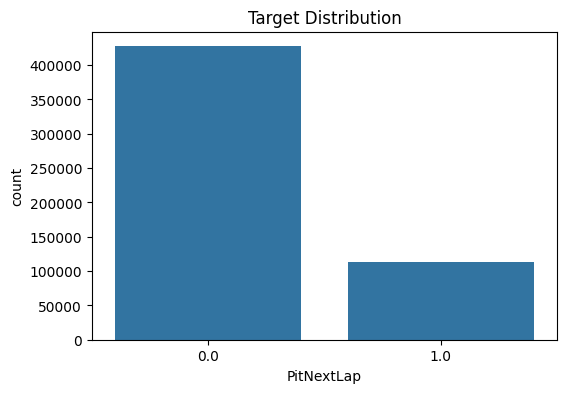

PitNextLap
0.0    0.79055
1.0    0.20945
Name: proportion, dtype: float64


In [9]:
# 4. Target Analysis

TARGET = "PitNextLap"
ID = "id"

plt.figure(figsize=(6,4))
sns.countplot(x=train[TARGET])
plt.title("Target Distribution")
plt.show()

print(train[TARGET].value_counts(normalize=True))

In [10]:
# 5. Basic EDA

num_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols = [c for c in num_cols if c not in [ID, TARGET]]

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 11
Categorical Columns: 3


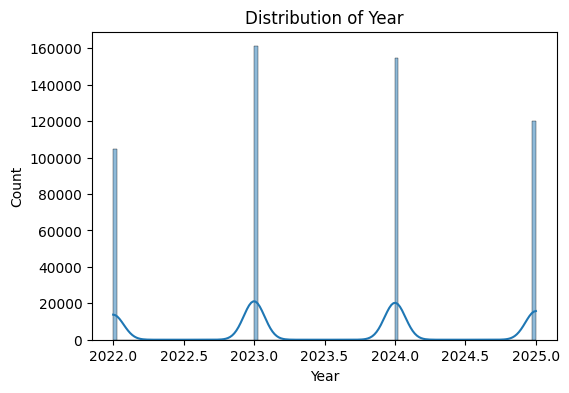

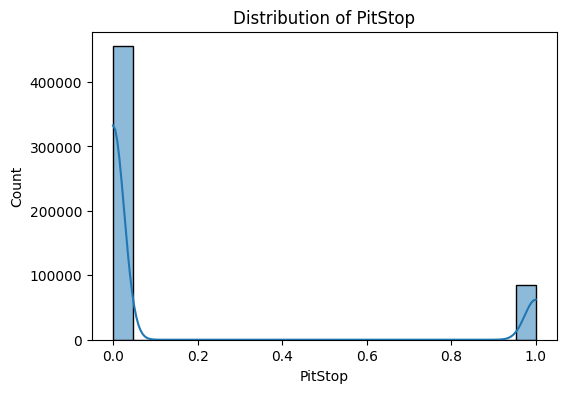

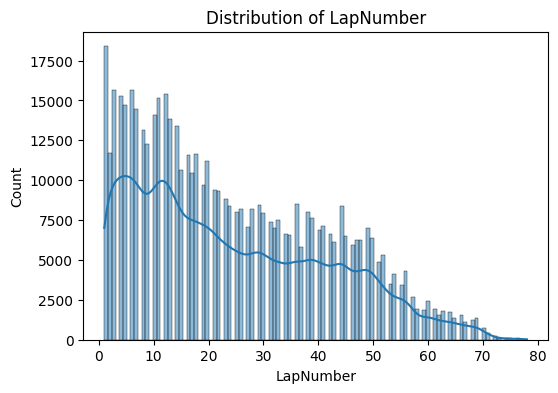

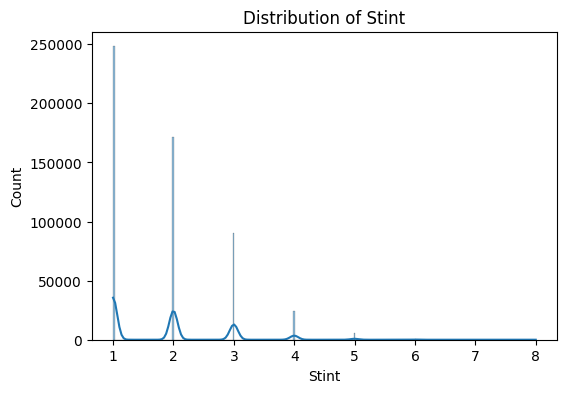

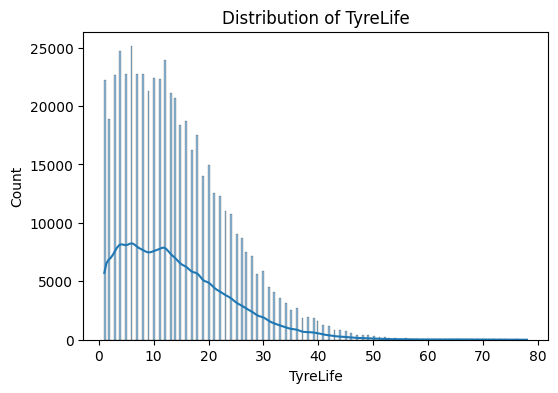

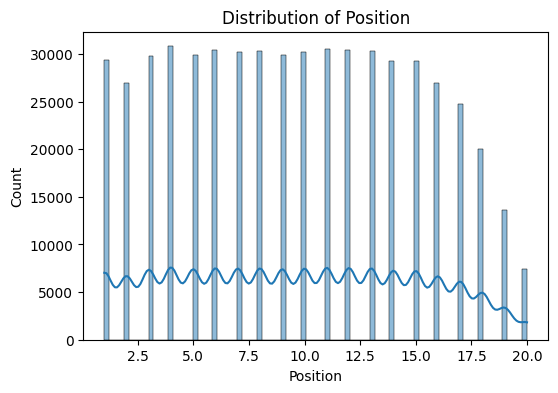

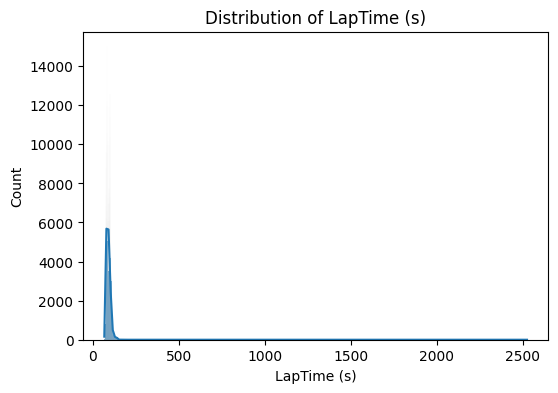

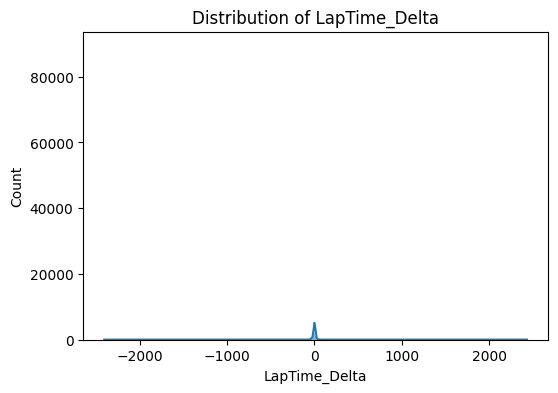

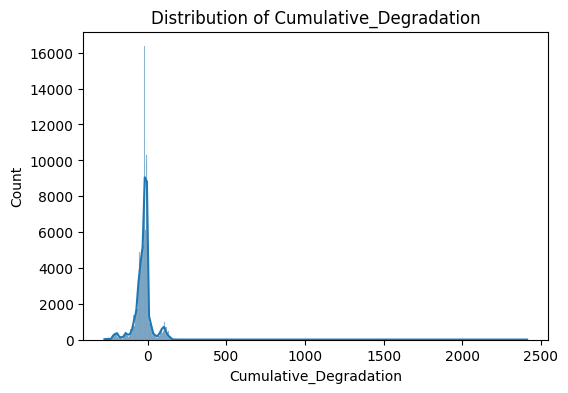

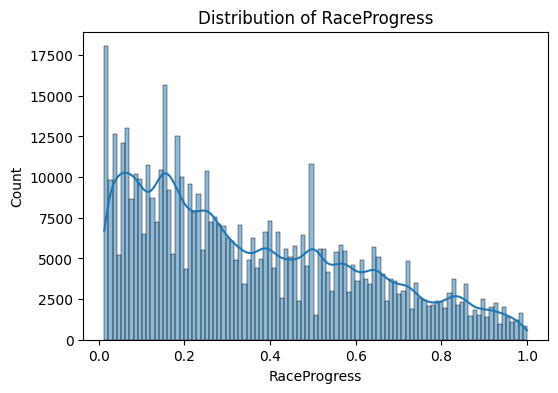

In [11]:
# Numerical Feature Distribution

for col in num_cols[:10]:
    plt.figure(figsize=(6,4))
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

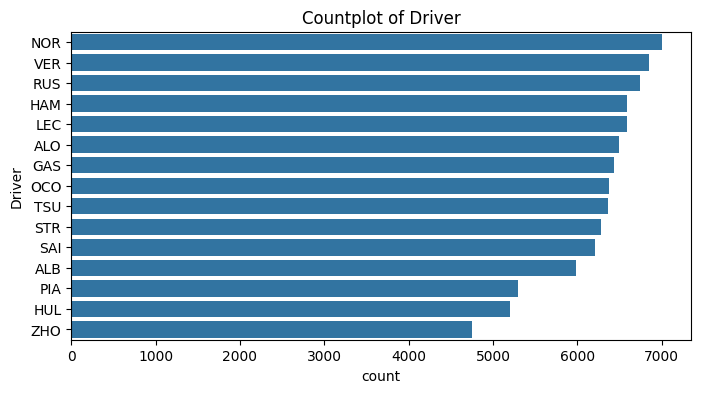

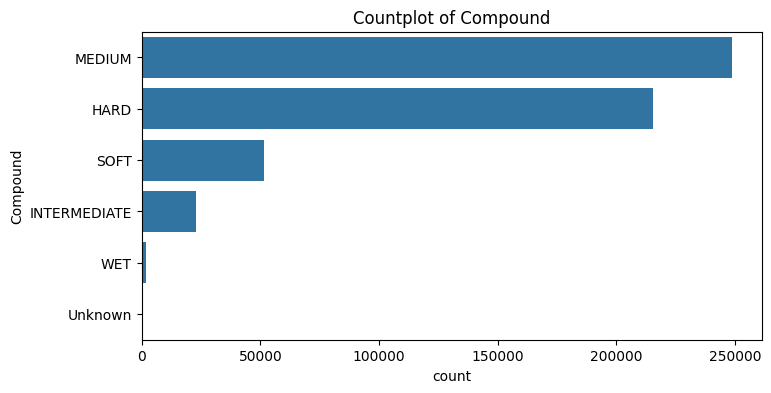

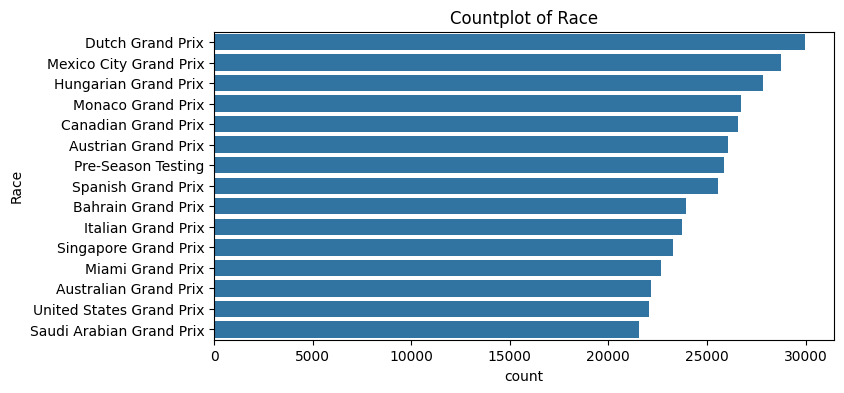

In [12]:
# Categorical Feature Countplot

for col in cat_cols[:10]:
    plt.figure(figsize=(8,4))
    sns.countplot(y=train[col], order=train[col].value_counts().index[:15])
    plt.title(f"Countplot of {col}")
    plt.show()

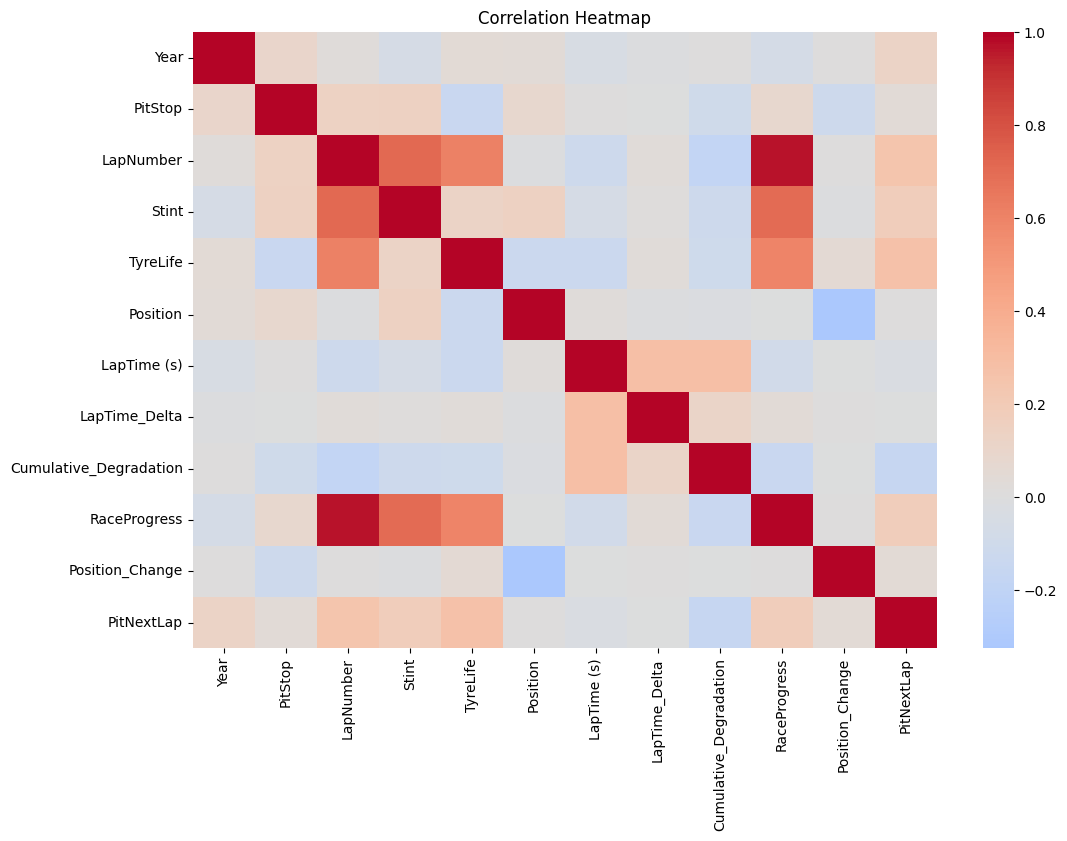

In [13]:
# Correlation Heatmap

corr_cols = num_cols + [TARGET]

plt.figure(figsize=(12,8))
sns.heatmap(train[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# 6. Feature Engineering

def feature_engineering(df):
    df = df.copy()
    
    # Basic row statistics for numeric columns
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in [ID, TARGET]]
    
    if len(numeric_cols) > 0:
        df["num_mean"] = df[numeric_cols].mean(axis=1)
        df["num_std"] = df[numeric_cols].std(axis=1)
        df["num_min"] = df[numeric_cols].min(axis=1)
        df["num_max"] = df[numeric_cols].max(axis=1)
        df["num_range"] = df["num_max"] - df["num_min"]
    
    # Common F1-style feature interactions if columns exist
    if "LapNumber" in df.columns and "Stint" in df.columns:
        df["lap_per_stint"] = df["LapNumber"] / (df["Stint"] + 1)
        
    if "TyreLife" in df.columns and "LapNumber" in df.columns:
        df["tyre_life_ratio"] = df["TyreLife"] / (df["LapNumber"] + 1)
        
    if "Position" in df.columns and "LapNumber" in df.columns:
        df["position_lap_interaction"] = df["Position"] * df["LapNumber"]
        
    return df


train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

print(train_fe.shape, test_fe.shape)

(540511, 23) (188165, 23)


In [15]:
# 7. Preprocessing

X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET]
X_test = test_fe.copy()

test_ids = X_test[ID]

#X = X.drop(columns=[ID])
X_test = X_test.drop(columns=[ID])

# Combine train and test for consistent encoding
combined = pd.concat([X, X_test], axis=0)

cat_cols = combined.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in cat_cols:
    combined[col] = combined[col].astype(str).fillna("missing")
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])

# Fill missing numeric values
combined = combined.fillna(combined.median(numeric_only=True))

X = combined.iloc[:len(X), :]
X_test = combined.iloc[len(X):, :]

print("Final Train Shape:", X.shape)
print("Final Test Shape:", X_test.shape)

Final Train Shape: (540511, 22)
Final Test Shape: (188165, 22)


In [16]:
# 8. Validation Strategy

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

In [17]:
# 9. Model Training Function

def train_model(model, X, y, X_test, model_name):
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    scores = []
    
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        print(f"\n===== {model_name} | Fold {fold+1} =====")
        
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        
        model.fit(X_train, y_train)
        
        valid_pred = model.predict_proba(X_valid)[:, 1]
        test_pred = model.predict_proba(X_test)[:, 1]
        
        oof_preds[valid_idx] = valid_pred
        test_preds += test_pred / N_SPLITS
        
        auc = roc_auc_score(y_valid, valid_pred)
        scores.append(auc)
        print(f"Fold {fold+1} ROC AUC: {auc:.5f}")
    
    mean_auc = np.mean(scores)
    print(f"\n{model_name} Mean ROC AUC: {mean_auc:.5f}")
    
    return oof_preds, test_preds, mean_auc

In [18]:
# 10. CatBoost Model

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    task_type='GPU'

)

cat_oof, cat_test, cat_score = train_model(
    cat_model, X, y, X_test, "CatBoost"
)


===== CatBoost | Fold 1 =====


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1 ROC AUC: 0.94392

===== CatBoost | Fold 2 =====


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2 ROC AUC: 0.94232

===== CatBoost | Fold 3 =====


...

Fold 3 ROC AUC: 0.94254

===== CatBoost | Fold 4 =====


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 4 ROC AUC: 0.94379

===== CatBoost | Fold 5 =====


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 5 ROC AUC: 0.94526

CatBoost Mean ROC AUC: 0.94357


In [19]:
# 11. LightGBM Model

lgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="binary",
    metric="auc",
    device_type='gpu'
)

lgbm_oof, lgbm_test, lgbm_score = train_model(
    lgbm_model, X, y, X_test, "LightGBM"
)


===== LightGBM | Fold 1 =====
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 90568, number of negative: 341840
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3262
[LightGBM] [Info] Number of data points in the train set: 432408, number of used features: 22
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 21 dense feature groups (9.90 MB) transferred to GPU in 0.009338 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.209450 -> initscore=-1.328242
[LightGBM] [Info] Start training from score -1.328242
Fold 1 ROC AUC: 0.95023

===== LightGBM | Fold 2 =====
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 90568, number of negative: 341841
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 432409, number of used features: 22
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 21 dense feature gro

In [20]:
# 12. XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42,
    tree_method="hist",
    device='cuda'
)

xgb_oof, xgb_test, xgb_score = train_model(
    xgb_model, X, y, X_test, "XGBoost"
)


===== XGBoost | Fold 1 =====
Fold 1 ROC AUC: 0.95144

===== XGBoost | Fold 2 =====
Fold 2 ROC AUC: 0.94988

===== XGBoost | Fold 3 =====
Fold 3 ROC AUC: 0.95044

===== XGBoost | Fold 4 =====
Fold 4 ROC AUC: 0.95103

===== XGBoost | Fold 5 =====
Fold 5 ROC AUC: 0.95232

XGBoost Mean ROC AUC: 0.95102


In [21]:
# 13. Model Comparison

model_scores = pd.DataFrame({
    "Model": ["CatBoost", "LightGBM", "XGBoost"],
    "CV ROC AUC": [cat_score, lgbm_score, xgb_score]
})

model_scores.sort_values("CV ROC AUC", ascending=False)

,Model,CV ROC AUC
2,XGBoost,0.951022
1,LightGBM,0.949541
0,CatBoost,0.943568


In [22]:
# 14. Ensemble

ensemble_oof = (
    0.4 * cat_oof +
    0.4 * lgbm_oof +
    0.2 * xgb_oof
)

ensemble_test = (
    0.4 * cat_test +
    0.4 * lgbm_test +
    0.2 * xgb_test
)

ensemble_score = roc_auc_score(y, ensemble_oof)

print("Ensemble ROC AUC:", ensemble_score)

Ensemble ROC AUC: 0.9484835206745781


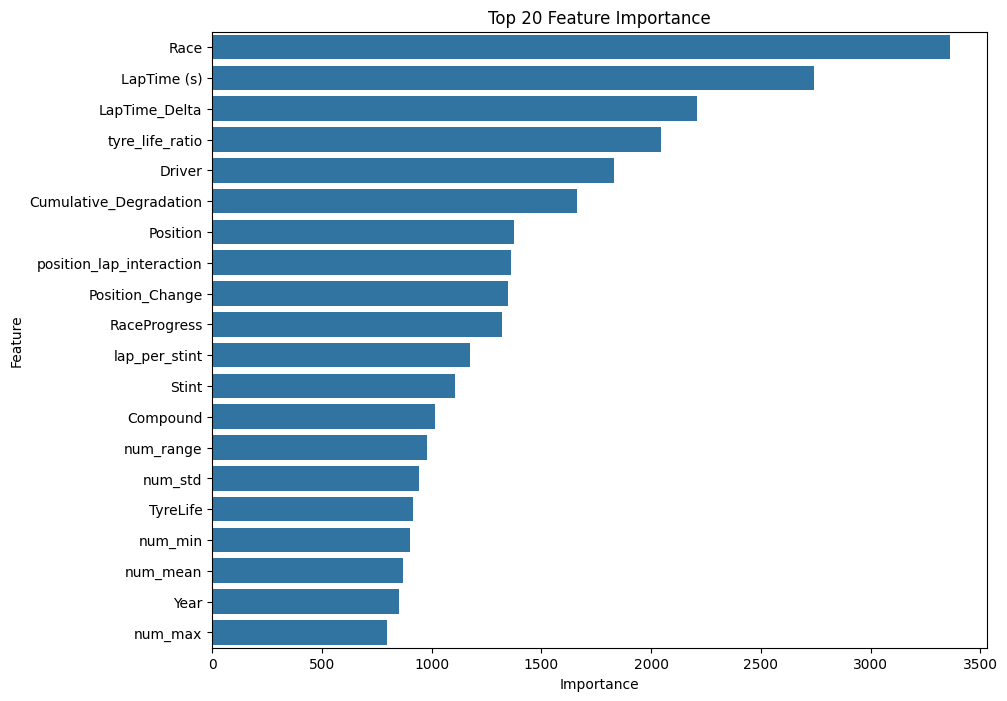

,Feature,Importance
2,Race,3364
9,LapTime (s),2743
10,LapTime_Delta,2209
20,tyre_life_ratio,2043
0,Driver,1831
11,Cumulative_Degradation,1661
8,Position,1373
21,position_lap_interaction,1361
13,Position_Change,1349
12,RaceProgress,1320


In [23]:
# 15. Feature Importance using LightGBM

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Feature Importance")
plt.show()

feature_importance.head(20)

In [24]:
# 16. Create Submission File

submission = pd.DataFrame({
    ID: test_ids,
    TARGET: ensemble_test
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,PitNextLap
0,439140,0.005781
1,439141,0.006941
2,439142,0.004673
3,439143,0.173671
4,439144,0.797345


In [25]:
# 17. Conclusion

print("Final CV Scores")
print(model_scores)
print("\nEnsemble CV ROC AUC:", ensemble_score)
print("\nSubmission file created: submission.csv")

Final CV Scores
      Model  CV ROC AUC
0  CatBoost    0.943568
1  LightGBM    0.949541
2   XGBoost    0.951022

Ensemble CV ROC AUC: 0.9484835206745781

Submission file created: submission.csv


# 🏎️ F1 Pit Stop Prediction | ROC AUC Optimized

In this notebook, we will build an end-to-end machine learning pipeline to predict whether a Formula 1 driver will pit on the next lap.

### Goal
Predict the probability of `PitNextLap`.

### Problem Type
Binary Classification

### Evaluation Metric
ROC AUC Score

### Target Variable
`PitNextLap`

# Re_Training to optimze

In [26]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [27]:
#train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/train.csv")
#test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/test.csv")
#sample_submission = pd.read_csv("/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Sample Submission Shape:", sample_submission.shape)

train.head()

Train Shape: (540511, 15)
Test Shape: (188165, 15)
Sample Submission Shape: (188165, 2)


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 4. Dataset Overview

Now we check dataset shape, column types, missing values, and duplicate rows.

In [28]:
print("Train Info:")
display(train.info())

print("Train Summary:")
display(train.describe())

print("Missing Values:")
display(train.isnull().sum())

print("Duplicate Rows:", train.duplicated().sum())

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540511 entries, 0 to 540510
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  540511 non-null  object 
 1   Compound                540511 non-null  object 
 2   Race                    540511 non-null  object 
 3   Year                    540511 non-null  int64  
 4   PitStop                 540511 non-null  int64  
 5   LapNumber               540511 non-null  int64  
 6   Stint                   540511 non-null  int64  
 7   TyreLife                540511 non-null  float64
 8   Position                540511 non-null  int64  
 9   LapTime (s)             540511 non-null  float64
 10  LapTime_Delta           540511 non-null  float64
 11  Cumulative_Degradation  540511 non-null  float64
 12  RaceProgress            540511 non-null  float64
 13  Position_Change         540511 non-null  float64
 14  PitNextL

None

Train Summary:


,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000,540511.000000
mean,2023.535948,0.157773,24.482301,1.837365,14.231582,9.654494,91.256021,-3.101221,-26.439742,0.355470,0.081628,0.209450
std,1.039448,0.364528,17.424550,0.955225,9.900556,5.303185,22.916342,44.233406,58.002225,0.256883,3.989509,0.406916
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.012000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,10.000000,1.000000,6.000000,5.000000,82.430000,-8.717000,-47.611500,0.141026,-1.000000,0.000000
50%,2024.000000,0.000000,21.000000,2.000000,12.000000,10.000000,90.648000,-0.226000,-21.068000,0.294872,0.000000,0.000000
75%,2024.000000,0.000000,38.000000,2.000000,20.000000,14.000000,98.632000,0.338000,-5.918000,0.541667,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,78.000000,20.000000,2526.253000,2433.472000,2412.431000,1.000000,18.000000,1.000000


Missing Values:


Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

Duplicate Rows: 0


## 5. Target Distribution

The target variable is `PitNextLap`.

- `0` means the driver will not pit on the next lap.
- `1` means the driver will pit on the next lap.

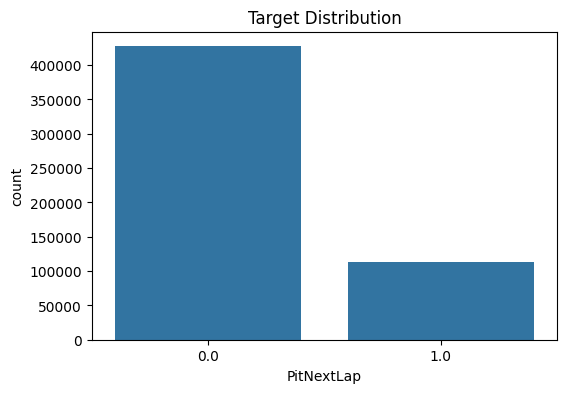

PitNextLap
0.0    427301
1.0    113210
Name: count, dtype: int64
PitNextLap
0.0    0.79055
1.0    0.20945
Name: proportion, dtype: float64


In [29]:
TARGET = "PitNextLap"
ID = "id"

plt.figure(figsize=(6,4))
sns.countplot(x=train[TARGET])
plt.title("Target Distribution")
plt.show()

print(train[TARGET].value_counts())
print(train[TARGET].value_counts(normalize=True))

## 6. Exploratory Data Analysis

We analyze numerical and categorical features to understand patterns.

In [30]:
num_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_cols = [col for col in num_cols if col not in [ID, TARGET]]

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
Categorical Columns: ['Driver', 'Compound', 'Race']


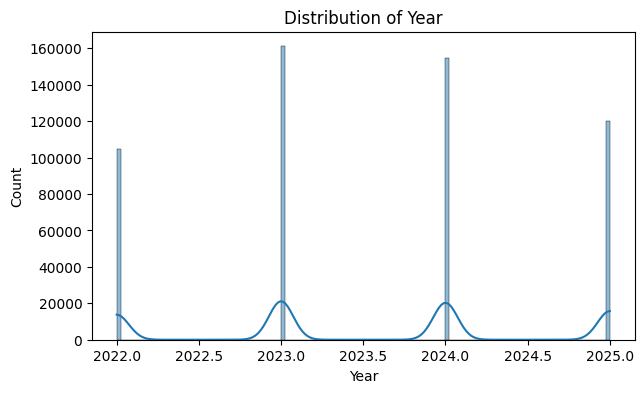

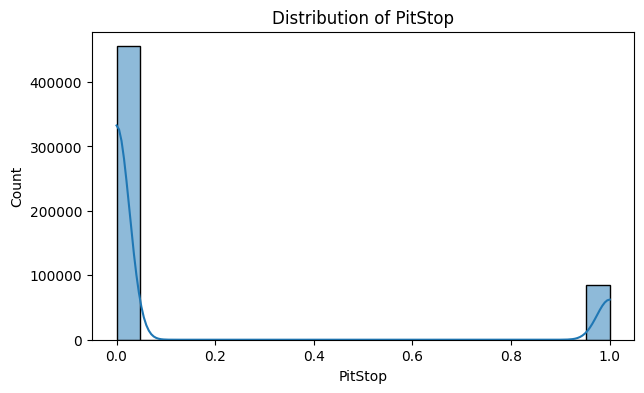

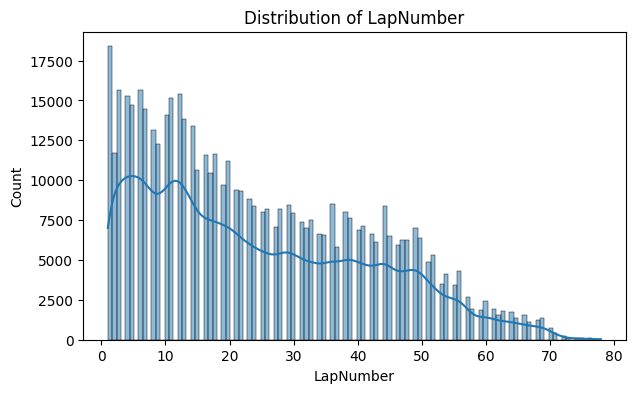

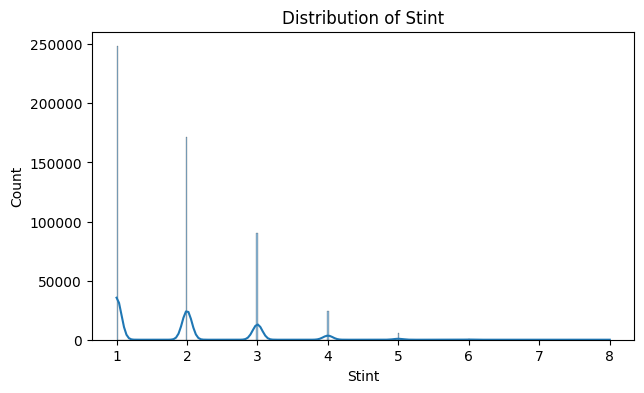

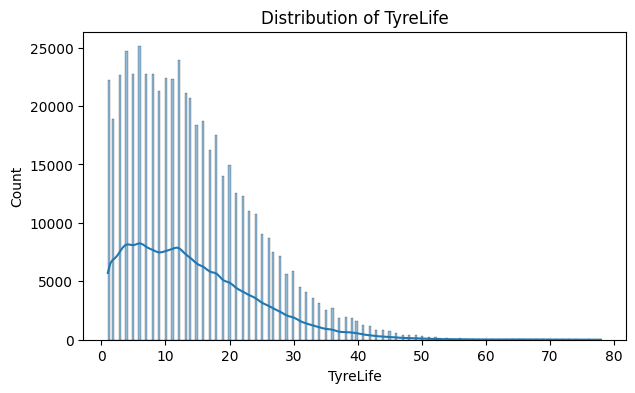

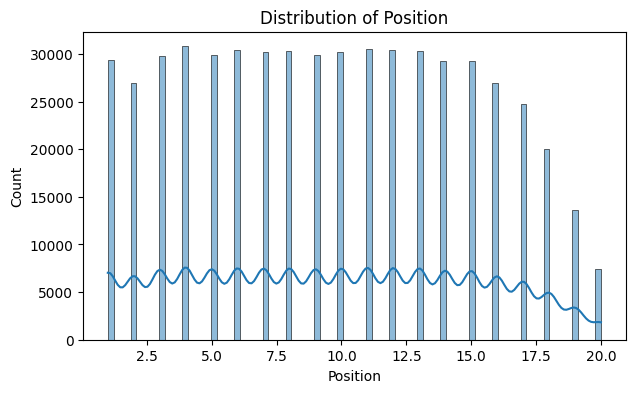

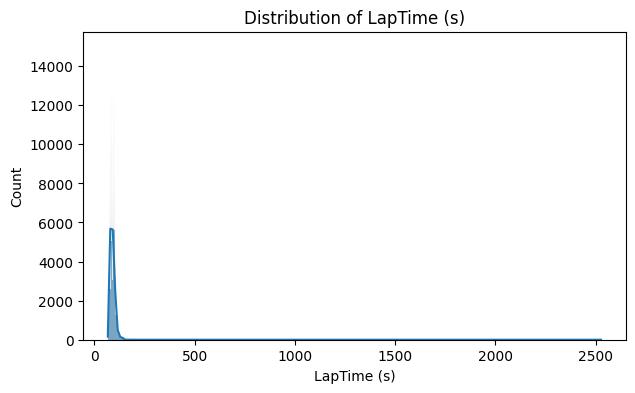

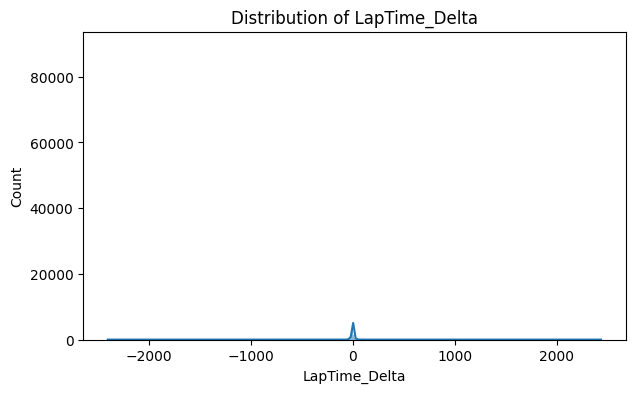

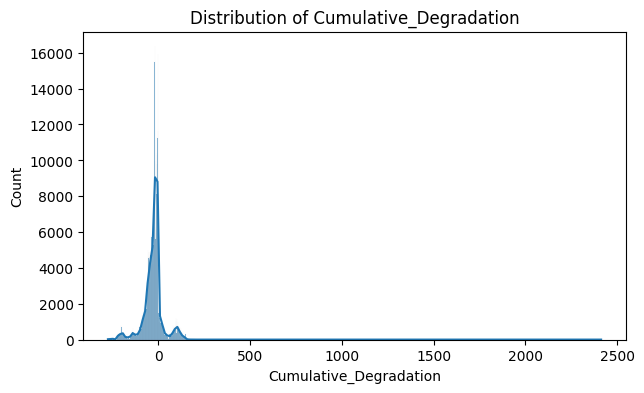

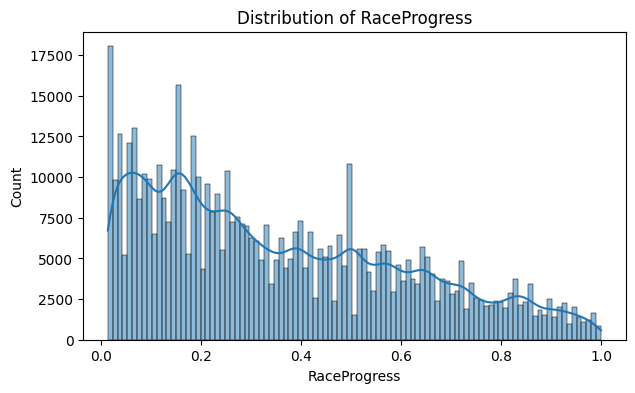

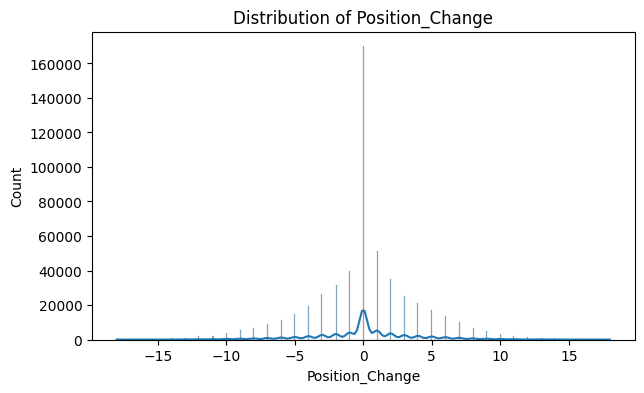

In [31]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

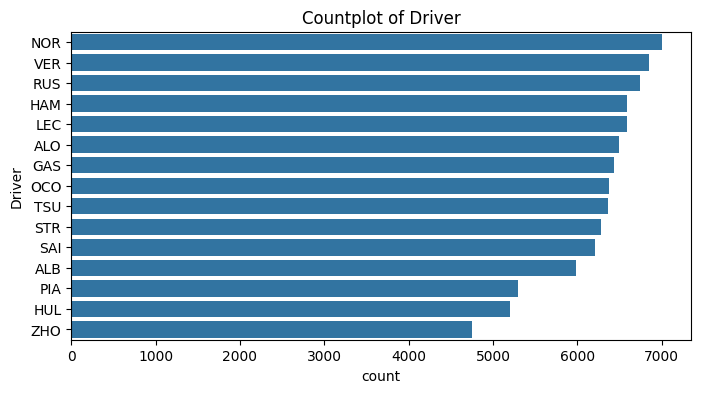

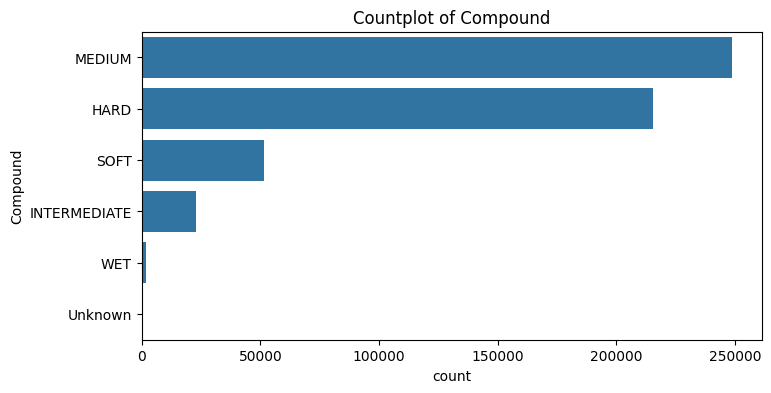

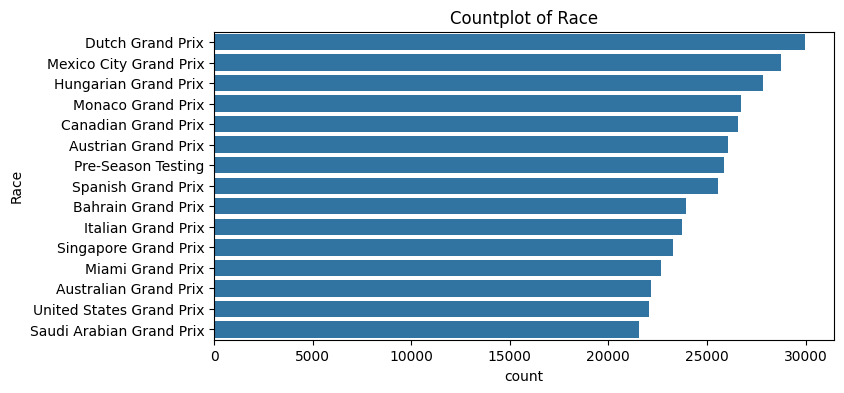

In [32]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=train[col], order=train[col].value_counts().index[:15])
    plt.title(f"Countplot of {col}")
    plt.show()

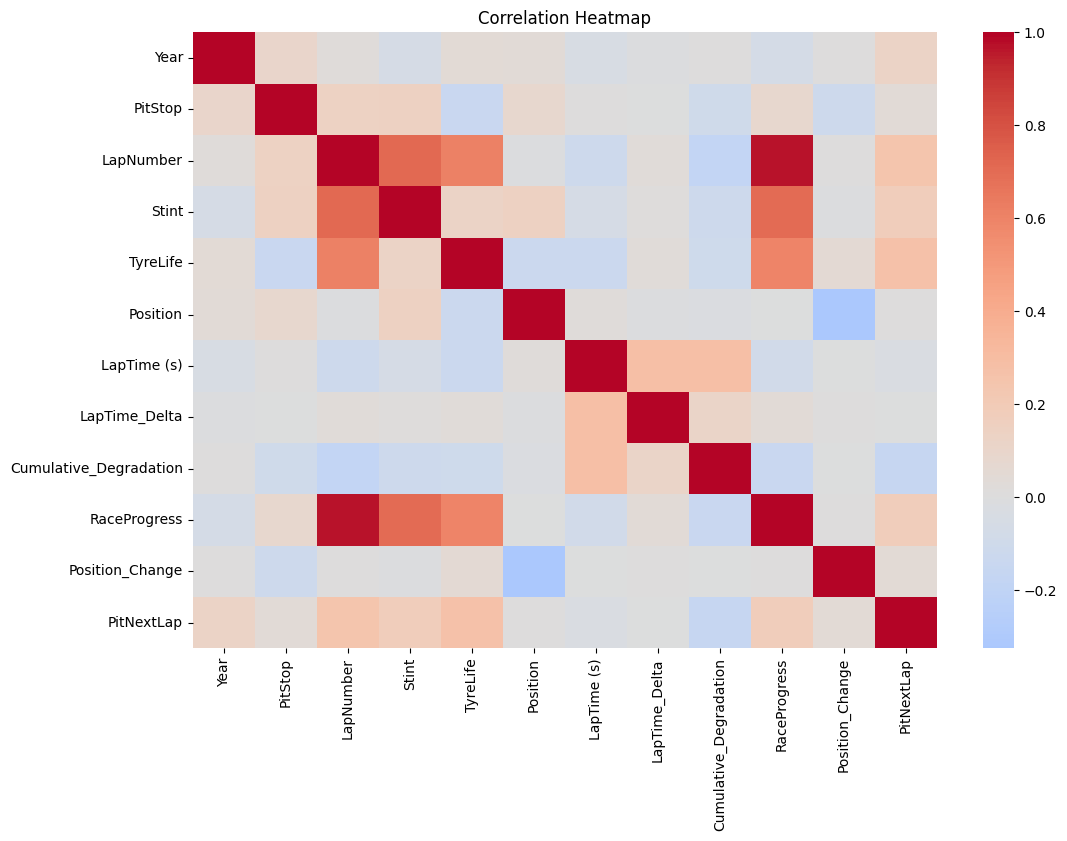

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(train[num_cols + [TARGET]].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 7. Feature Engineering

We create new features based on tyre age, race progress, lap time, position, and degradation.

In [34]:
def create_features(df):
    df = df.copy()
    
    if "TyreLife" in df.columns and "LapNumber" in df.columns:
        df["tyre_life_ratio"] = df["TyreLife"] / (df["LapNumber"] + 1)
        df["tyre_life_x_lap"] = df["TyreLife"] * df["LapNumber"]
    
    if "TyreLife" in df.columns and "Cumulative_Degradation" in df.columns:
        df["tyre_degradation_pressure"] = df["TyreLife"] * df["Cumulative_Degradation"]
    
    if "RaceProgress" in df.columns:
        df["early_race"] = (df["RaceProgress"] < 0.33).astype(int)
        df["mid_race"] = ((df["RaceProgress"] >= 0.33) & (df["RaceProgress"] < 0.66)).astype(int)
        df["late_race"] = (df["RaceProgress"] >= 0.66).astype(int)
    
    if "LapTime (s)" in df.columns and "Position" in df.columns:
        df["lap_time_per_position"] = df["LapTime (s)"] / (df["Position"] + 1)
    
    if "Position_Change" in df.columns:
        df["abs_position_change"] = df["Position_Change"].abs()
    
    if "Position" in df.columns and "Position_Change" in df.columns:
        df["position_pressure"] = df["Position"] * df["Position_Change"].abs()
    
    if "Stint" in df.columns and "TyreLife" in df.columns:
        df["stint_tyre_interaction"] = df["Stint"] * df["TyreLife"]
    
    if "PitStop" in df.columns and "TyreLife" in df.columns:
        df["pitstop_tyre_interaction"] = df["PitStop"] * df["TyreLife"]
    
    return df


train_fe = create_features(train)
test_fe = create_features(test)

print("Train FE Shape:", train_fe.shape)
print("Test FE Shape:", test_fe.shape)

Train FE Shape: (540511, 26)
Test FE Shape: (188165, 26)


## 8. Data Preprocessing

We separate features and target, encode categorical columns, and handle missing values.

In [35]:
X = train_fe.drop(columns=[TARGET])
y = train_fe[TARGET]

X_test = test_fe.copy()
test_ids = X_test[ID]

#X = X.drop(columns=[ID])
X_test = X_test.drop(columns=[ID])

combined = pd.concat([X, X_test], axis=0).reset_index(drop=True)

cat_cols = combined.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in cat_cols:
    combined[col] = combined[col].astype(str)
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])

combined = combined.fillna(combined.median(numeric_only=True))

X = combined.iloc[:len(train), :]
X_test = combined.iloc[len(train):, :]

print("Final X Shape:", X.shape)
print("Final Test Shape:", X_test.shape)

Final X Shape: (540511, 25)
Final Test Shape: (188165, 25)


## 9. Validation Strategy

We use Stratified K-Fold Cross Validation because the target is imbalanced.

In [36]:
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

## 10. Model Training Function

This function trains a model using StratifiedKFold and returns OOF predictions, test predictions, and ROC AUC score.

In [37]:
def train_model(model, X, y, X_test, model_name):
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    scores = []
    
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        print(f"\n========== {model_name} | Fold {fold+1} ==========")
        
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]
        
        model.fit(X_train, y_train)
        
        valid_preds = model.predict_proba(X_valid)[:, 1]
        test_fold_preds = model.predict_proba(X_test)[:, 1]
        
        oof_preds[valid_idx] = valid_preds
        test_preds += test_fold_preds / N_SPLITS
        
        auc = roc_auc_score(y_valid, valid_preds)
        scores.append(auc)
        
        print(f"Fold {fold+1} ROC AUC: {auc:.6f}")
    
    mean_auc = np.mean(scores)
    print(f"\n{model_name} Mean ROC AUC: {mean_auc:.6f}")
    
    return oof_preds, test_preds, mean_auc

## 11. CatBoost Model

In [38]:
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
    #task_type='GPU'
)

cat_oof, cat_test, cat_score = train_model(
    cat_model,
    X,
    y,
    X_test,
    "CatBoost"
)


========== CatBoost | Fold 1 ==========
Fold 1 ROC AUC: 0.944349

========== CatBoost | Fold 2 ==========
Fold 2 ROC AUC: 0.942495

========== CatBoost | Fold 3 ==========
Fold 3 ROC AUC: 0.943138

========== CatBoost | Fold 4 ==========
Fold 4 ROC AUC: 0.944203

========== CatBoost | Fold 5 ==========
Fold 5 ROC AUC: 0.945627

CatBoost Mean ROC AUC: 0.943962


## 12. LightGBM Model

In [39]:
lgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="binary",
    device_type='gpu'
)

lgbm_oof, lgbm_test, lgbm_score = train_model(
    lgbm_model,
    X,
    y,
    X_test,
    "LightGBM"
)


========== LightGBM | Fold 1 ==========
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 90568, number of negative: 341840
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 2928
[LightGBM] [Info] Number of data points in the train set: 432408, number of used features: 25
[LightGBM] [Info] Using GPU Device: Tesla P100-PCIE-16GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 21 dense feature groups (9.90 MB) transferred to GPU in 0.009027 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.209450 -> initscore=-1.328242
[LightGBM] [Info] Start training from score -1.328242
Fold 1 ROC AUC: 0.949496

========== LightGBM | Fold 2 ==========
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[L

## 13. XGBoost Model

In [40]:
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42,
    tree_method="hist",
    device='gpu'
)

xgb_oof, xgb_test, xgb_score = train_model(
    xgb_model,
    X,
    y,
    X_test,
    "XGBoost"
)


========== XGBoost | Fold 1 ==========
Fold 1 ROC AUC: 0.950698

========== XGBoost | Fold 2 ==========
Fold 2 ROC AUC: 0.949323

========== XGBoost | Fold 3 ==========
Fold 3 ROC AUC: 0.950210

========== XGBoost | Fold 4 ==========
Fold 4 ROC AUC: 0.950634

========== XGBoost | Fold 5 ==========
Fold 5 ROC AUC: 0.951743

XGBoost Mean ROC AUC: 0.950522


## 14. Model Comparison

In [41]:
model_scores = pd.DataFrame({
    "Model": ["CatBoost", "LightGBM", "XGBoost"],
    "ROC AUC": [cat_score, lgbm_score, xgb_score]
})

model_scores = model_scores.sort_values("ROC AUC", ascending=False)
model_scores

,Model,ROC AUC
2,XGBoost,0.950522
1,LightGBM,0.949175
0,CatBoost,0.943962


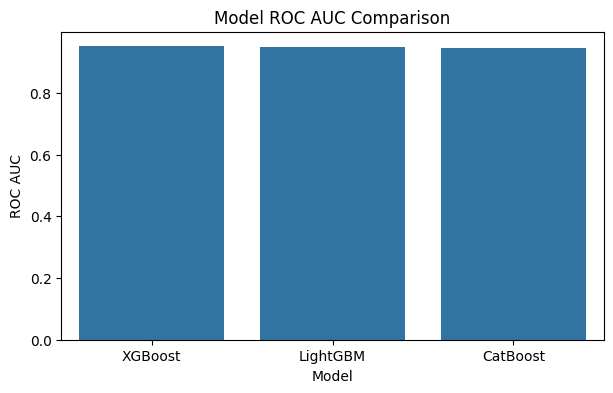

In [42]:
plt.figure(figsize=(7,4))
sns.barplot(data=model_scores, x="Model", y="ROC AUC")
plt.title("Model ROC AUC Comparison")
plt.show()

## 15. Ensemble

We combine predictions from CatBoost, LightGBM, and XGBoost using weighted average.

In [43]:
ensemble_oof = (
    0.40 * cat_oof +
    0.40 * lgbm_oof +
    0.20 * xgb_oof
)

ensemble_test = (
    0.40 * cat_test +
    0.40 * lgbm_test +
    0.20 * xgb_test
)

ensemble_score = roc_auc_score(y, ensemble_oof)

print("Ensemble ROC AUC:", ensemble_score)

Ensemble ROC AUC: 0.9482480016095158


## 16. Feature Importance

We use LightGBM feature importance to understand which features are most useful.

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(20)

,Feature,Importance
2,Race,3318
9,LapTime (s),2805
11,Cumulative_Degradation,2667
10,LapTime_Delta,2426
14,tyre_life_ratio,2008
0,Driver,1853
20,lap_time_per_position,1846
12,RaceProgress,1608
3,Year,1480
6,Stint,1137


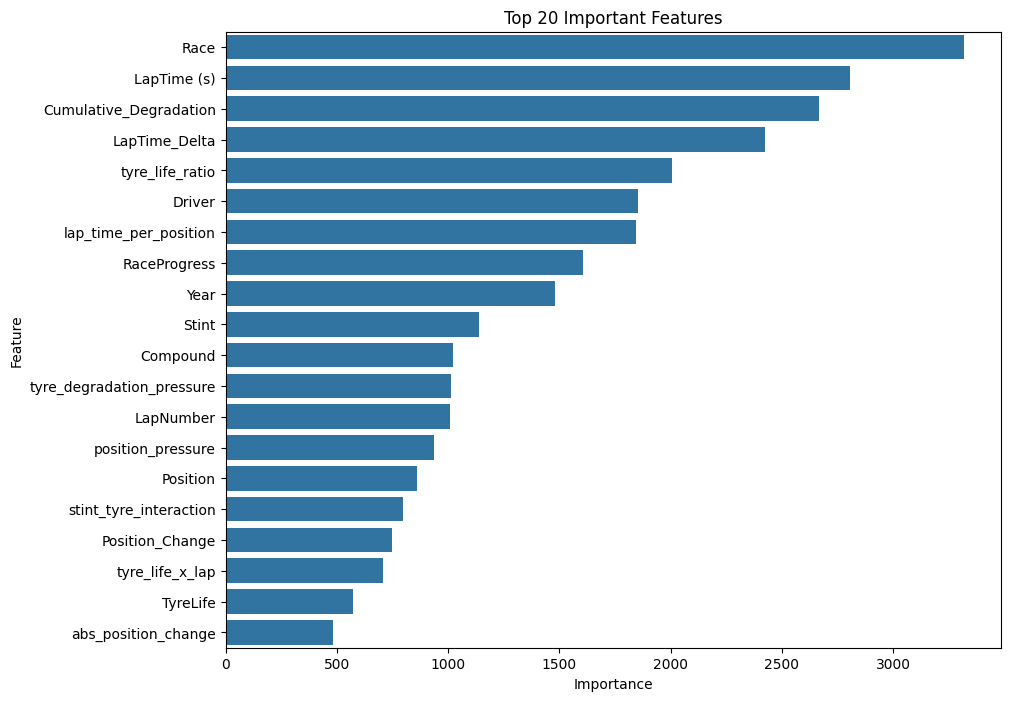

In [45]:
plt.figure(figsize=(10,8))
sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Important Features")
plt.show()

## 17. Create Final Submission File

The competition requires probability predictions for `PitNextLap`.

In [46]:
submission = pd.DataFrame({
    "id": test_ids,
    "PitNextLap": ensemble_test
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,PitNextLap
0,439140,0.004548
1,439141,0.004051
2,439142,0.003748
3,439143,0.194465
4,439144,0.788253
